# Week 3 — Fitting a Linear Model, and Inference on Its Coefficients

**Maths for Data Science II**

This notebook works through the full argument on `patients_cross_section_2026.csv`:

1. Fitting `sbp ~ age + bmi + chol` by OLS
2. **The sampling distribution of $\hat\beta$** — where all inference comes from
3. **The $t$-test** — is a single coefficient different from zero (or from any other value)?
4. **Confidence intervals** — what they do and do not mean, verified by simulation
5. **The $F$-test** — testing several restrictions at once, and why that is not the same as testing them one at a time

The unifying theme: a coefficient estimate is a *random variable*. Everything below is about quantifying how much it would have moved had we drawn a different sample of 200 patients.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan, het_white, linear_reset
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence

pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams["figure.dpi"] = 110

## 2. Choosing the dataset

Four datasets are available in this folder. They are not interchangeable — the data *structure* dictates which estimator is valid.

| File | Structure | Suitable for plain OLS? |
|---|---|---|
| `patients_cross_section_2026.csv` | 200 patients, one row each, single time point | **Yes** — independent observations |
| `patient1_time_series_2024_2025.csv` | 1 patient, 24 monthly observations | No — serially correlated errors |
| `panel_50patients_24months.csv` | 50 patients × 24 months | No — needs fixed/random effects |
| pooled cross-sections | repeated samples over time | Only with time dummies |

Ordinary least squares assumes **independent** errors. In the time-series and panel files, consecutive readings on the same patient are strongly dependent, so the standard errors from naive OLS would be badly understated. The cross-section is the one file where the independence assumption is defensible by construction: each row is a different person, sampled once.

In [2]:
URL = ("https://raw.githubusercontent.com/thousandoaks/Maths4DS-III/"
       "refs/heads/main/datasets/patients_cross_section_2026.csv")

df = pd.read_csv(URL)


print(f"shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

shape: 200 rows x 8 columns


,patient_id,age,sex,smoker,bmi,sbp,chol,cost
0,1,25,0,1,27.8000,123.0000,218.0000,379.2900
1,2,66,1,1,28.1000,144.0000,238.0000,"1,724.0200"
2,3,59,0,0,27.1000,143.0000,204.0000,705.5300
3,4,46,1,0,20.3000,142.0000,205.0000,506.1800
4,5,45,0,0,16.8000,116.0000,187.0000,852.5400


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
patient_id,200.0000,100.5000,57.8792,1.0000,50.7500,100.5000,150.2500,200.0000
age,200.0000,50.0450,16.4928,20.0000,36.7500,50.0000,65.0000,79.0000
sex,200.0000,0.4600,0.4996,0.0000,0.0000,0.0000,1.0000,1.0000
smoker,200.0000,0.2600,0.4397,0.0000,0.0000,0.0000,1.0000,1.0000
bmi,200.0000,25.7910,3.9888,14.1000,23.1750,25.8500,28.2000,36.4000
sbp,200.0000,136.9050,12.4123,104.0000,128.0000,138.0000,145.0000,177.0000
chol,200.0000,220.0250,23.5691,146.0000,205.0000,219.0000,235.2500,304.0000
cost,200.0000,877.5163,513.2045,216.3300,526.4800,732.1100,"1,048.5525","3,025.8900"


## 3. Statistical Distribution of Variables
We screen the candidate response variables. Shapiro–Wilk tests the null hypothesis that the sample is drawn from a normal distribution — a **large** $p$-value means we fail to reject normality, which here is the outcome we want.

In [4]:
rows = []
for col in ["age", "bmi", "sbp", "chol", "cost"]:
    x = df[col]
    sw = stats.shapiro(x)
    rows.append({
        "variable": col,
        "mean": x.mean(),
        "std": x.std(),
        "skew": stats.skew(x),
        "excess kurtosis": stats.kurtosis(x),
        "Shapiro W": sw.statistic,
        "Shapiro p": sw.pvalue,
        "normal?": "yes" if sw.pvalue > 0.05 else "NO",
    })

normality = pd.DataFrame(rows).set_index("variable")
normality

,mean,std,skew,excess kurtosis,Shapiro W,Shapiro p,normal?
variable,,,,,,,
age,50.0450,16.4928,-0.0850,-1.1341,0.9582,0.0000,NO
bmi,25.7910,3.9888,-0.1275,0.0515,0.9957,0.8409,yes
sbp,136.9050,12.4123,0.1491,0.0927,0.9945,0.6756,yes
chol,220.0250,23.5691,-0.0156,0.6292,0.9941,0.6199,yes
cost,877.5163,513.2045,1.7367,3.6506,0.8468,0.0000,NO


Reading this table carefully:

- **`sbp`, `chol`, `bmi`** are all comfortably consistent with normality ($p > 0.6$), with skew near zero.
- **`cost`** is emphatically not: skew $\approx 1.7$, $p < 0.001$. It is a strictly positive, right-skewed monetary variable — the classic case for a log transform or a Gamma GLM.
- **`age`** also fails, but this is a red herring. It is approximately *uniform* on [20, 80] by design. Age is a **predictor**, and predictors face no distributional assumption whatsoever. A failed normality test on a regressor is not a problem.

**We take **`sbp`** as the response and **`age`, `bmi`, `chol`** as quantitative regressors.**

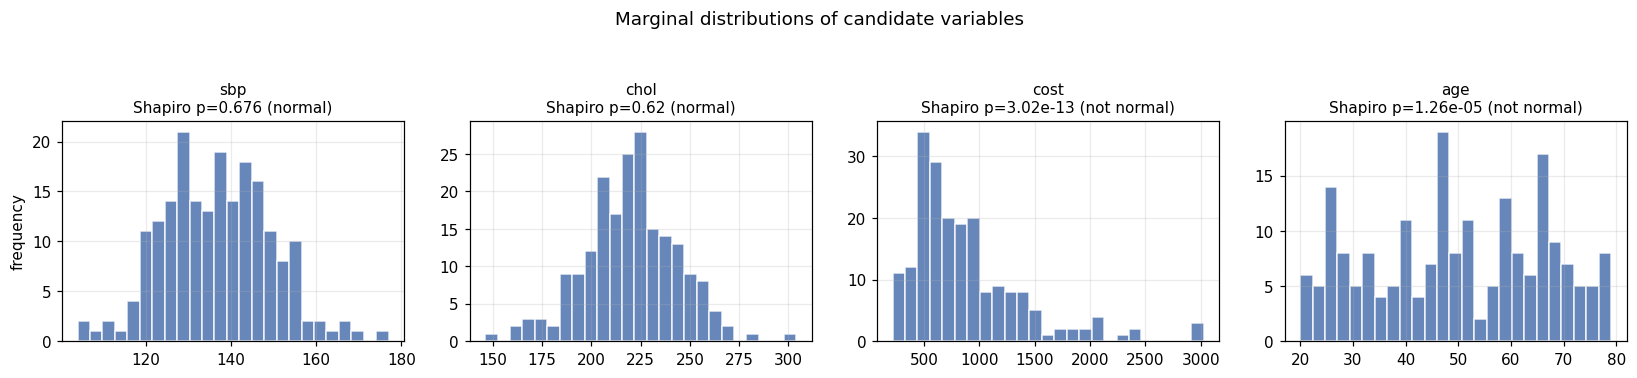

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))
for ax, col in zip(axes, ["sbp", "chol", "cost", "age"]):
    ax.hist(df[col], bins=25, color="#4C72B0", edgecolor="white", alpha=.85)
    p = stats.shapiro(df[col]).pvalue
    verdict = "normal" if p > .05 else "not normal"
    ax.set_title(f"{col}\nShapiro p={p:.3g} ({verdict})", fontsize=10)
    ax.grid(alpha=.25)
axes[0].set_ylabel("frequency")
fig.suptitle("Marginal distributions of candidate variables", y=1.06, fontsize=12)
plt.tight_layout()
plt.show()

### Correlation structure

Before fitting, check that the regressors relate to the response but not excessively to each other.

         age     bmi   chol    sbp
age   1.0000 -0.0030 0.3590 0.6180
bmi  -0.0030  1.0000 0.2560 0.3270
chol  0.3590  0.2560 1.0000 0.4080
sbp   0.6180  0.3270 0.4080 1.0000


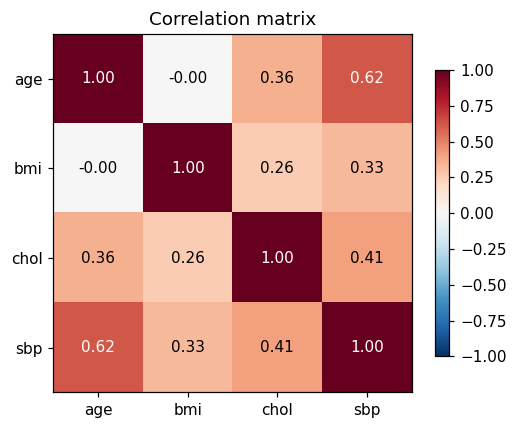

In [6]:
corr = df[["age", "bmi", "chol", "sbp"]].corr()
print(corr.round(3))

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns)
ax.set_yticks(range(len(corr)), corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if abs(v) > 0.6 else "black", fontsize=10)
fig.colorbar(im, ax=ax, shrink=.8)
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()

`age`–`sbp` is the strongest association at 0.62; `bmi` and `chol` contribute 0.33 and 0.41. Critically, `age`–`bmi` is essentially **0.00**, so the regressors carry largely non-overlapping information. That is a good sign for a well-conditioned design matrix.

## 4. Fitting the model

$$ \texttt{sbp}_i = \beta_0 + \beta_1\,\texttt{age}_i + \beta_2\,\texttt{bmi}_i + \beta_3\,\texttt{chol}_i + \varepsilon_i $$

Note `sm.add_constant` — statsmodels does not include an intercept unless you ask for one.

In [7]:
predictors = ["age", "bmi", "chol"]
X = sm.add_constant(df[predictors])
y = df["sbp"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    sbp   R-squared:                       0.503
Model:                            OLS   Adj. R-squared:                  0.495
Method:                 Least Squares   F-statistic:                     66.03
Date:                Fri, 31 Jul 2026   Prob (F-statistic):           1.50e-29
Time:                        07:57:02   Log-Likelihood:                -717.18
No. Observations:                 200   AIC:                             1442.
Df Residuals:                     196   BIC:                             1456.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         76.8322      6.436     11.937      0.0

### Interpretation

$$ \widehat{\texttt{sbp}} = 76.83 + 0.431\,\texttt{age} + 0.922\,\texttt{bmi} + 0.067\,\texttt{chol} $$

- Each additional **year of age** raises predicted systolic BP by **0.43 mmHg**, holding BMI and cholesterol fixed. Over a decade, ≈ 4.3 mmHg.
- Each additional **BMI point** raises it by **0.92 mmHg**. So roughly 4.7 BMI points ≈ one decade of ageing.
- The intercept (76.83 mmHg at age 0, BMI 0, cholesterol 0) is **not interpretable** — it lies far outside the data. Centring the predictors would fix this if the intercept mattered.



---

## 5. Where inference comes from: the sampling distribution of $\hat\beta$

The estimates in the table above came from *one* sample of 200 patients. Draw a different 200 and every number would change. Inference is the discipline of saying how much.

Under the classical assumptions ($\varepsilon \sim \mathcal{N}(0,\sigma^2)$, i.i.d., $X$ fixed), the OLS estimator is a linear function of $y$, hence itself normal:

$$ \hat\beta \sim \mathcal{N}\!\left(\beta,\ \sigma^2 (X^\top X)^{-1}\right) $$

It is **unbiased** ($\mathbb{E}[\hat\beta] = \beta$), and the standard error of $\hat\beta_j$ is the square root of the $j$-th diagonal element of that covariance matrix.

The complication: $\sigma^2$ is unknown. We replace it with $s^2 = \hat\varepsilon^\top\hat\varepsilon/(n-k)$. Substituting an *estimated* variance costs us the normal distribution and buys a **$t$ distribution** with $n-k$ degrees of freedom:

$$ \frac{\hat\beta_j - \beta_j}{\operatorname{se}(\hat\beta_j)} \sim t_{n-k} $$

This single pivotal quantity generates both the $t$-tests and the confidence intervals that follow. Here $n=200$, $k=4$, so $n-k=196$ — large enough that $t_{196}$ is nearly standard normal, but we use the exact distribution regardless.

In [8]:
n, k = X.shape
df_resid = n - k

resid = model.resid
s2 = resid @ resid / df_resid
XtX_inv = np.linalg.inv(X.values.T @ X.values)
cov_beta = s2 * XtX_inv
se_manual = np.sqrt(np.diag(cov_beta))

print(f"n = {n},  k = {k} (incl. intercept),  residual df = n - k = {df_resid}")
print(f"s^2 = {s2:.4f}   ->   s = {np.sqrt(s2):.4f} mmHg  (typical prediction error)\n")

pd.DataFrame({
    "coef": model.params,
    "se (statsmodels)": model.bse,
    "se (manual)": se_manual,
}).round(6)

n = 200,  k = 4 (incl. intercept),  residual df = n - k = 196
s^2 = 77.7967   ->   s = 8.8202 mmHg  (typical prediction error)



,coef,se (statsmodels),se (manual)
const,76.8322,6.4364,6.4364
age,0.4313,0.0408,0.0408
bmi,0.9223,0.1630,0.1630
chol,0.0668,0.0296,0.0296


The manual standard errors reproduce statsmodels exactly — they are just $\sqrt{s^2 (X^\top X)^{-1}_{jj}}$.

Below, the full estimated covariance matrix $\widehat{\operatorname{Var}}(\hat\beta)$. The off-diagonal entries matter: they record how the estimates co-vary across hypothetical repeated samples, and they are exactly what the $F$-test in Section 8 uses and the individual $t$-tests ignore.

In [9]:
cov_df = pd.DataFrame(cov_beta, index=X.columns, columns=X.columns)
print("Estimated covariance matrix of the coefficients:")
print(cov_df.round(6).to_string())

corr_beta = cov_df / np.outer(se_manual, se_manual)
print("\nImplied correlations between estimates:")
print(corr_beta.round(3).to_string())

Estimated covariance matrix of the coefficients:
        const     age     bmi    chol
const 41.4270 -0.0028 -0.4290 -0.1356
age   -0.0028  0.0017  0.0007 -0.0004
bmi   -0.4290  0.0007  0.0266 -0.0013
chol  -0.1356 -0.0004 -0.0013  0.0009

Implied correlations between estimates:
        const     age     bmi    chol
const  1.0000 -0.0100 -0.4090 -0.7130
age   -0.0100  1.0000  0.1050 -0.3720
bmi   -0.4090  0.1050  1.0000 -0.2750
chol  -0.7130 -0.3720 -0.2750  1.0000


Note the strong *negative* correlation between the intercept and the slopes. That is not a defect — it reflects that the fitted plane must pass through the centroid of the data, so an upward tilt in a slope must be offset by a lower intercept. It also explains why "each coefficient is individually fine" does not imply "the coefficients are jointly fine".

---

## 6. The $t$-test: is one coefficient different from zero?

### 6.1 The logic

For each regressor, statsmodels reports a test of

$$ H_0: \beta_j = 0 \qquad \text{against} \qquad H_1: \beta_j \neq 0 $$

The test statistic is simply the estimate divided by its own standard error:

$$ t_j = \frac{\hat\beta_j - 0}{\operatorname{se}(\hat\beta_j)} \ \sim\ t_{n-k} \ \text{ under } H_0 $$

Read it as **"how many standard errors is the estimate away from zero?"** If $H_0$ were true, $t_j$ would rarely stray far from 0. A large $|t_j|$ is therefore evidence against $H_0$.

Two equivalent decision rules at significance level $\alpha = 0.05$:

- **Critical value:** reject if $|t_j| > t_{0.975,\,196} = 1.972$
- **$p$-value:** reject if $p_j < 0.05$, where $p_j = 2\,P(T_{196} > |t_j|)$

The factor of 2 is because the alternative is two-sided: we would be equally surprised by a large negative estimate.

In [10]:
t_crit = stats.t.ppf(0.975, df_resid)

t_manual = model.params / model.bse
p_manual = 2 * stats.t.sf(np.abs(t_manual), df_resid)

ttests = pd.DataFrame({
    "coef": model.params,
    "std err": model.bse,
    "t = coef/se": t_manual,
    "p-value": p_manual,
    "|t| > 1.972?": np.where(np.abs(t_manual) > t_crit, "reject H0", "fail to reject"),
})

print(f"Critical value  t(0.975, {df_resid}) = {t_crit:.4f}\n")
print(ttests.to_string(float_format=lambda v: f"{v:12.6g}"))
print(f"\nMatches statsmodels? t: {np.allclose(t_manual, model.tvalues)}"
      f"   p: {np.allclose(p_manual, model.pvalues)}")

Critical value  t(0.975, 196) = 1.9721

              coef      std err  t = coef/se      p-value |t| > 1.972?
const      76.8322      6.43638      11.9372  4.84135e-25    reject H0
age       0.431309    0.0408392      10.5611  6.29162e-21    reject H0
bmi       0.922254     0.163039      5.65663  5.40844e-08    reject H0
chol     0.0668199     0.029559      2.26056    0.0248857    reject H0

Matches statsmodels? t: True   p: True


**Conclusions.** All three slopes are significant at the 5% level, but they are not remotely equally strong:

| term | $t$ | reading |
|---|---|---|
| `age` | 10.56 | over ten standard errors from zero — overwhelming |
| `bmi` | 5.66 | very strong |
| `chol` | 2.26 | *just* past the 1.972 threshold, $p = 0.025$ |

`chol` clears the bar, but only barely. Had we set $\alpha = 0.01$ (critical value 2.601) it would not have. A coefficient sitting this close to the boundary deserves scepticism rather than a verdict.

### 6.2 Visualising what the test does

The $t$ statistic is a position on the $t_{196}$ density. The shaded tails are the rejection region — the 5% of outcomes we would treat as "too extreme to be chance" if $H_0$ were true.

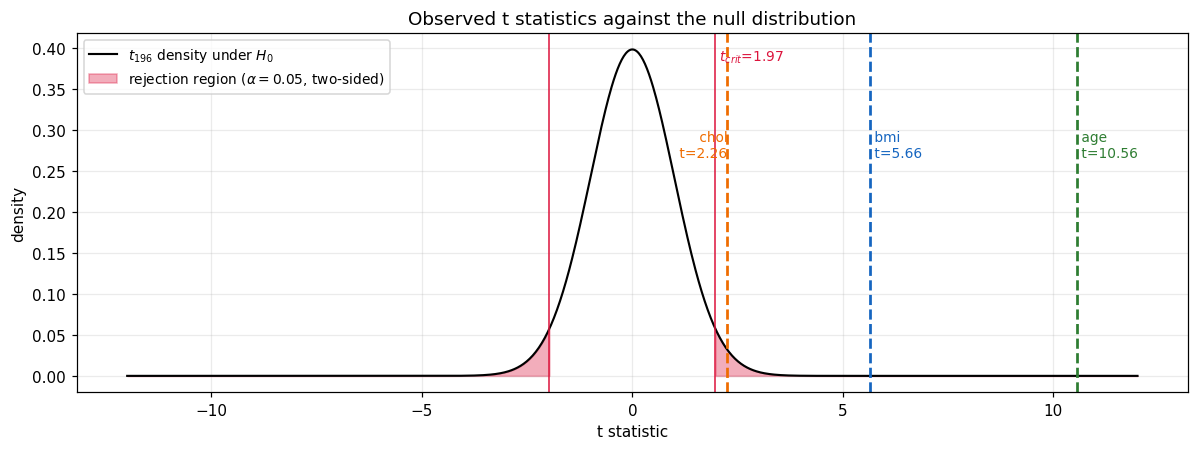

In [11]:
fig, ax = plt.subplots(figsize=(11, 4.2))
xs = np.linspace(-12, 12, 1000)
ax.plot(xs, stats.t.pdf(xs, df_resid), color="black", lw=1.4, label=f"$t_{{{df_resid}}}$ density under $H_0$")

tail = np.linspace(t_crit, 12, 200)
ax.fill_between(tail, stats.t.pdf(tail, df_resid), color="crimson", alpha=.35,
                label=r"rejection region ($\alpha=0.05$, two-sided)")
ax.fill_between(-tail, stats.t.pdf(-tail, df_resid), color="crimson", alpha=.35)

colors = {"age": "#2E7D32", "bmi": "#1565C0", "chol": "#EF6C00"}
for name, col in colors.items():
    t_obs = model.tvalues[name]
    ax.axvline(t_obs, color=col, lw=1.8, ls="--")
    ax.text(t_obs, 0.30, f" {name}\n t={t_obs:.2f}", color=col, fontsize=9,
            ha="left" if name != "chol" else "right", va="top")

ax.axvline(t_crit, color="crimson", lw=1); ax.axvline(-t_crit, color="crimson", lw=1)
ax.text(t_crit, 0.385, f" $t_{{crit}}$={t_crit:.2f}", color="crimson", fontsize=9)
ax.set(xlabel="t statistic", ylabel="density",
       title="Observed t statistics against the null distribution")
ax.legend(loc="upper left", fontsize=9); ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

`chol` sits only just inside the red region; `age` is off in the far tail where the null density is numerically indistinguishable from zero.

---

## 7. Confidence intervals

### 7.1 Construction

Inverting the same pivot gives an interval rather than a verdict:

$$ \hat\beta_j \ \pm\ t_{1-\alpha/2,\,n-k}\times \operatorname{se}(\hat\beta_j) $$

For 95% confidence and 196 degrees of freedom the multiplier is 1.972 — the familiar "roughly two standard errors".

In [12]:
ci = model.conf_int(alpha=0.05)
ci.columns = ["2.5%", "97.5%"]

ci_table = pd.DataFrame({
    "coef": model.params,
    "std err": model.bse,
    "2.5%": ci["2.5%"],
    "97.5%": ci["97.5%"],
    "width": ci["97.5%"] - ci["2.5%"],
    "contains 0?": np.where((ci["2.5%"] <= 0) & (ci["97.5%"] >= 0), "YES", "no"),
})

print(f"Multiplier: t(0.975, {df_resid}) = {t_crit:.4f}\n")
print(ci_table.round(4).to_string())

Multiplier: t(0.975, 196) = 1.9721

         coef  std err    2.5%   97.5%   width contains 0?
const 76.8322   6.4364 64.1388 89.5257 25.3869          no
age    0.4313   0.0408  0.3508  0.5118  0.1611          no
bmi    0.9223   0.1630  0.6007  1.2438  0.6431          no
chol   0.0668   0.0296  0.0085  0.1251  0.1166          no


### 7.2 Interpretation — the part that is almost always got wrong

For `age` the interval is $[0.351,\ 0.512]$.


> **Right:**  Values between roughly 0.35 and 0.51 mmHg per year are consistent with our data. A rise of 0.35 mmHg/year and a rise of 0.51 mmHg/year would both be unsurprising; 0.20 would not.



---

## 8. The $F$-test: several restrictions at once

### 8.1 Why a separate test is needed

With three $t$-tests at $\alpha=0.05$ each, the chance of at least one false positive under a global null is $1-0.95^3 \approx 14\%$, not 5%. Testing coefficients *jointly* controls this. More fundamentally, the $t$-tests examine coefficients one at a time and so discard the covariance structure from Section 5 — the $F$-test uses it.

### 8.2 The overall $F$-test

Reported at the top of every regression summary:

$$ H_0: \beta_{\texttt{age}} = \beta_{\texttt{bmi}} = \beta_{\texttt{chol}} = 0 \qquad \text{(the model has no explanatory power)} $$

It compares our model against an intercept-only model, in terms of variance explained:

$$ F = \frac{R^2/(k-1)}{(1-R^2)/(n-k)} \ \sim\ F_{k-1,\,n-k} \ \text{ under } H_0 $$

In [13]:
r2 = model.rsquared
F_manual = (r2 / (k - 1)) / ((1 - r2) / df_resid)
p_F = stats.f.sf(F_manual, k - 1, df_resid)

print("OVERALL F-TEST   H0: all slopes = 0")
print(f"  R^2 = {r2:.6f}")
print(f"  F = ({r2:.4f}/{k-1}) / ((1-{r2:.4f})/{df_resid}) = {F_manual:.4f}")
print(f"  statsmodels F = {model.fvalue:.4f}   agree: {np.isclose(F_manual, model.fvalue)}")
print(f"  df = ({k-1}, {df_resid})")
print(f"  critical value at 5% = {stats.f.ppf(0.95, k-1, df_resid):.4f}")
print(f"  p-value = {p_F:.3e}")
print(f"\n  -> F = {model.fvalue:.1f} vastly exceeds {stats.f.ppf(0.95, k-1, df_resid):.2f}. "
      f"Reject H0 emphatically.")

OVERALL F-TEST   H0: all slopes = 0
  R^2 = 0.502656
  F = (0.5027/3) / ((1-0.5027)/196) = 66.0312
  statsmodels F = 66.0312   agree: True
  df = (3, 196)
  critical value at 5% = 2.6507
  p-value = 1.496e-29

  -> F = 66.0 vastly exceeds 2.65. Reject H0 emphatically.


---

## 9. Summary

### The three procedures

| | **$t$-test** | **$F$-test** | **Confidence interval** |
|---|---|---|---|
| Question | is $\beta_j = c$? | are $q$ restrictions jointly true? | which values are plausible? |
| Statistic | $(\hat\beta_j - c)/\operatorname{se}$ | $\dfrac{(\text{RSS}_r-\text{RSS}_u)/q}{\text{RSS}_u/(n-k)}$ | $\hat\beta_j \pm t_{crit}\operatorname{se}$ |
| Distribution | $t_{n-k}$ | $F_{q,\,n-k}$ | inverts the $t$ pivot |
| Output | reject / fail to reject | reject / fail to reject | a range, with units |

All three descend from the same fact: $\hat\beta \sim \mathcal{N}(\beta, \sigma^2(X^\top X)^{-1})$, with $t$ replacing the normal once $\sigma$ is estimated.

### Results for this model

- **Overall $F$** = 66.03 on $(3, 196)$ df, $p \approx 1.5\times10^{-29}$ — the model has real explanatory power.
- **`age`**: 0.431 mmHg/year, $t = 10.56$, 95% CI $[0.351, 0.512]$. Strongest effect.
- **`bmi`**: 0.922 mmHg/point, $t = 5.66$, 95% CI $[0.601, 1.244]$. Strong.
- **`chol`**: 0.067, $t = 2.26$, 95% CI $[0.009, 0.125]$ — barely clears 5%, interval nearly touches zero. Weak evidence.
- $\beta_{\texttt{age}} = 0.5$ **cannot** be rejected ($p = 0.094$), despite $\beta_{\texttt{age}} = 0$ being rejected decisively.
- $\beta_{\texttt{age}} = \beta_{\texttt{bmi}}$ **is** rejected ($F = 8.98$, $p = 0.003$).
- Simulation confirmed 94.7% coverage against a nominal 95%.

### Five things worth remembering

1. **A confidence interval is a statement about the procedure, not the parameter.** The parameter is fixed; the interval is random.
2. **CIs and $t$-tests are the same statement**, but the interval reports effect size and precision instead of a bare verdict. Prefer it.
3. **"Significant" means "distinguishable from zero"** — nothing about importance, magnitude, or causality. With $n$ large enough, trivial effects become significant.
4. **Individual $t$-tests are conditional on all other regressors.** Under collinearity they can all be insignificant while the block is jointly decisive.
5. **Confidence intervals for a mean $\ne$ prediction intervals for an individual.** Only the first shrinks with more data.

### A closing caveat

Every procedure here assumes the model is correctly specified. Inference is conditional on that assumption — a beautifully tight confidence interval around a biased estimate is precisely wrong rather than approximately right. The diagnostics (residual normality, homoscedasticity, functional form) are what license these tests; and no diagnostic can detect a genuinely omitted variable.